In [ ]:
%load_ext autoreload
%autoreload 2

## Data Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from collections import Counter

In [ ]:
df = pd.read_excel("../data/Training-data.xlsx")
print(df.head())

In [ ]:
test1 = pd.read_excel("../data/Test-data-1.xlsx")

In [ ]:
test2 = pd.read_excel("../data/Test-data-2.xlsx")

## Data Preparation (non-learned steps)

### Irrelevant Features

In [ ]:
df1 = df.drop(columns=["tcprtt"])

### Missing Values

In [ ]:
# No empty values for now

### Duplicated Values

In [ ]:
df2 = df1.drop(columns=["is_ftp_login"])

### Feature Attribute Selection

In [ ]:
df3 = df2.drop(columns=['dwin'])

### Feature Engineering

In [ ]:
# Empty for now

### Class Imbalance

In [ ]:
# Empty for now

## Cross Validation setup

In [ ]:
from sklearn.model_selection import StratifiedKFold, KFold, ShuffleSplit

skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=67
)

y = df3['label']
X = df3.drop(columns=['label'])


numeric_cols = X.select_dtypes(include=['number']).columns
categorical_cols = X.select_dtypes(include=['string']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), categorical_cols)
    ]
)

## k-NN Classifier

### k-NN: Build a pipeline 

In [234]:
# k_values = [1,3,7,11,17,21]
k_values = [7]

def make_knn_pipeline(k):
    return Pipeline([
        ("preprocessor", preprocessor),                 
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

### k-NN: Evaluate different k-values with CV

In [ ]:
cv_records = []
for k in k_values:
    print("Training on k = {}".format(k))
    pipe = make_knn_pipeline(k)
    scores = cross_val_score(pipe, X, y, cv=skf, scoring="accuracy", n_jobs=-1)
    cv_records.append({"k": k, "mean_cv_acc": scores.mean(), "std_cv_acc": scores.std()})

### k-NN: Select the champion model


Cross-validation accuracy by k (training set):
 k  mean_cv_acc  std_cv_acc
 7     0.994145     0.00031
Best k: 7


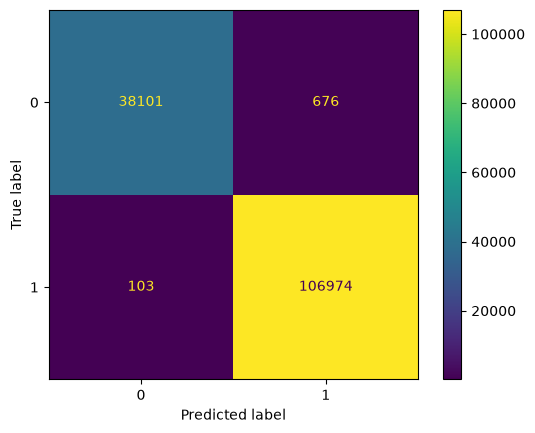

In [235]:
cv_df = pd.DataFrame(cv_records).sort_values("mean_cv_acc", ascending=False).reset_index(drop=True)
print("\nCross-validation accuracy by k (training set):")
print(cv_df.to_string(index=False))

best_k = cv_df.loc[0, 'k']
print("Best k: {}".format(best_k))

pipe = make_knn_pipeline(best_k)
pipe.fit(X,y)

fig, ax = plt.subplots(1,1)
ConfusionMatrixDisplay.from_estimator(
    pipe,
    X, y,
    ax = ax
    )

## Decision Tree classifier

### DT: Build a pipeline

In [ ]:
def make_dt_pipeline():
    return Pipeline([
        ("preprocessor", preprocessor),                 
        ("dt", DecisionTreeClassifier())
    ])

### DT: Evaluate different hyperparameters

In [ ]:
parameters = {
    'dt__criterion': ('entropy', 'gini'),
    'dt__min_samples_split' : list(range(3,11))
    }

gscv = GridSearchCV(
    estimator=make_dt_pipeline(),
    param_grid=parameters,
    cv=skf,
    scoring='accuracy'
)

best_dtc = gscv.fit(X, y)

In [ ]:
best_dtc = gscv.fit(X, y)
best_dtc.best_params_, best_dtc.best_score_

### DT: Select the champion model

{'dt__criterion': 'gini', 'dt__min_samples_split': 4}
0.9940557047931666


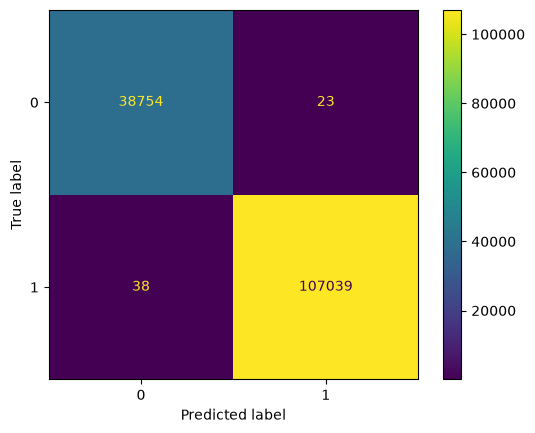

In [232]:
print(best_dtc.best_params_)
print(best_dtc.best_score_)

fig, ax = plt.subplots(1,1)
ConfusionMatrixDisplay.from_estimator(
    best_dtc,
    X, y,
    ax = ax
    )

## Naive-Bayes classifier

### NB: Build a pipeline

In [ ]:
def make_nb_pipeline():
    return Pipeline([
        ("preprocessor", preprocessor),                 
        ("nb", GaussianNB())
    ])

### NB: Evaluate different hyperparameters

In [239]:
parameters = {
    "nb__var_smoothing": [
        1e-12, 1e-11, 1e-10, 1e-9,
        1e-8, 1e-7, 1e-6
    ]
}

gscv = GridSearchCV(
    estimator=make_nb_pipeline(),
    param_grid=parameters,
    cv=skf,
    scoring='accuracy',
)

gscv.fit(X, y)

ValueError: 
All the 70 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
63 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/henphan/Documents/GitHub/Data-Mining-Assignment/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 855, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/henphan/Documents/GitHub/Data-Mining-Assignment/.venv/lib/python3.14/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/henphan/Documents/GitHub/Data-Mining-Assignment/.venv/lib/python3.14/site-packages/sklearn/pipeline.py", line 645, in fit
    self._final_estimator.fit(Xt, y, **last_step_params

### NB: Select the champion model

{'nb__var_smoothing': 1e-06}
0.4430046487958525


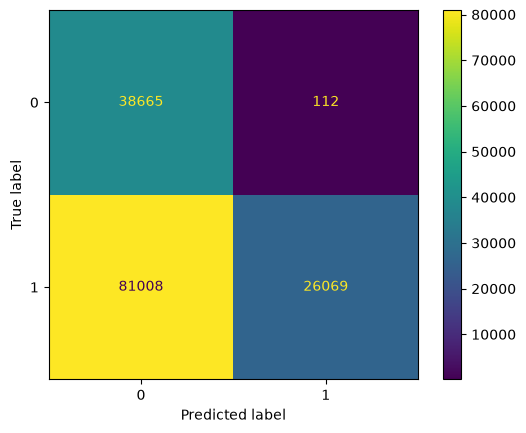

In [231]:
print(gscv.best_params_)
print(gscv.best_score_)

fig, ax = plt.subplots(1,1)
ConfusionMatrixDisplay.from_estimator(
    gscv,
    X, y,
    ax = ax
    )